In [1]:
%%capture
%pip install --upgrade pip
%pip install "Pillow==9.5.0" wordcloud nltk urllib3~=2.0
!pip uninstall xgboost -y
!pip install "xgboost==1.7.6" --no-cache-dir

In [2]:
!pip install pandas numpy matplotlib seaborn tqdm scikit-learn nltk xgboost Pillow wordcloud


Defaulting to user installation because normal site-packages is not writeable


In [3]:
%%capture
from tqdm import tqdm
import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
import multiprocessing
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from scipy.stats import uniform, loguniform


import string
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import wordnet
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

####
from xgboost import XGBClassifier
import xgboost as xgb

####
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

sns.set_context('notebook')
sns.set_style('white')

In [4]:
tweets = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-GPXX0DYDEN/twitterv3.csv')

In [6]:
tweets.head(3)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0


In [8]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tweet_id                 1372 non-null   int64  
 1   author_id                1372 non-null   object 
 2   inbound                  1372 non-null   bool   
 3   created_at               1372 non-null   object 
 4   text                     1372 non-null   object 
 5   response_tweet_id        931 non-null    object 
 6   in_response_to_tweet_id  1022 non-null   float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 65.8+ KB


In [14]:
df = tweets
df['new_text'] = df['text'].str.lower()
df.sample(3)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
371,665,AmazonHelp,False,Tue Oct 31 22:19:29 +0000 2017,@115843 You're not lion! She even shows witch ...,666,667.0,@115843 you're not lion! she even shows witch ...
206,295,115780,True,Tue Oct 31 17:01:38 +0000 2017,@115777 your online forum is always broken eve...,294,NaN,@115777 your online forum is always broken eve...
376,670,115844,True,Tue Oct 31 22:15:42 +0000 2017,@115845 They sent the feckin' order to Germany...,668,671.0,@115845 they sent the feckin' order to germany...


In [9]:
nltk.download('punkt_tab')

True

In [10]:
def negate(sentence):
    temp = int(0)
    for i in range(len(sentence)):
        if sentence[i-1] in ['not',"n't"]:
            antonyms = []
            for syn in wordnet.synsets(sentence[i]):
                syns = wordnet.synsets(sentence[i])
                w1 = syns[0].name()
                temp = 0
                for l in syn.lemmas():
                    if l.antonyms():
                        antonyms.append(l.antonyms()[0].name())
                        max_dissimilarity = 0
                        for ant in antonyms:
                            syns = wordnet.synsets(ant)
                            w2 = syns[0].name()
                            syns = wordnet.synsets(sentence[i])
                            w1 = syns[0].name()
                            word1 = wordnet.synset(w1)
                            word2 = wordnet.synset(w2)
                            if isinstance(word1.wup_similarity(word2), float) or isinstance(word1.wup_similarity(word2), int):
                                temp = 1 - word1.wup_similarity(word2)
                                if temp>max_dissimilarity:
                                    max_dissimilarity = temp
                                    antonym_max = ant
                                    sentence[i] = antonym_max
                                    sentence[i-1] = ''
    while '' in sentence:
        sentence.remove('')
    return sentence

In [13]:
sentence = word_tokenize("he isn't happy")
print(negate(sentence))

['he', 'is', 'unhappy']


In [15]:
df['new_text'] = df['new_text'].apply(lambda x: negate(word_tokenize(x)))
df.head(5)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0,"[@, 115712, i, understand, ., i, would, like, ..."
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,"[@, sprintcare, and, how, do, you, propose, we..."
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0,"[@, sprintcare, i, have, sent, several, privat..."
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0,"[@, 115712, please, send, us, a, private, mess..."
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,"[@, sprintcare, i, did, .]"


In [16]:
pd.set_option('display.max_colwidth', None)
df[['text', 'new_text']].head(5)

,text,new_text
0,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,"[@, 115712, i, understand, ., i, would, like, to, assist, you, ., we, would, need, to, get, you, into, a, private, secured, link, to, further, assist, .]"
1,@sprintcare and how do you propose we do that,"[@, sprintcare, and, how, do, you, propose, we, do, that]"
2,@sprintcare I have sent several private messages and no one is responding as usual,"[@, sprintcare, i, have, sent, several, private, messages, and, no, one, is, responding, as, usual]"
3,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,"[@, 115712, please, send, us, a, private, message, so, that, we, can, further, assist, you, ., just, click, ‘, message, ’, at, the, top, of, your, profile, .]"
4,@sprintcare I did.,"[@, sprintcare, i, did, .]"


In [17]:
def unlist(list):
    words=''
    for item in list:
        words+=item+' '
    return words

df['new_text'] = df['new_text'].apply(lambda x: unlist(x))
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0,@ 115712 i understand . i would like to assist you . we would need to get you into a private secured link to further assist .
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,@ sprintcare and how do you propose we do that
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0,@ sprintcare i have sent several private messages and no one is responding as usual
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0,@ 115712 please send us a private message so that we can further assist you . just click ‘ message ’ at the top of your profile .
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,@ sprintcare i did .


In [19]:
punc = string.punctuation
print("The punctuation signs in Python are: " + punc)

The punctuation signs in Python are: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [20]:
def delete_punc(text):
    text_wo_punc = text.translate(str.maketrans("", "", punc))
    return text_wo_punc

df['new_text'] = df['new_text'].apply(lambda text: delete_punc(text))
df.head(20)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0,115712 i understand i would like to assist you we would need to get you into a private secured link to further assist
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,sprintcare and how do you propose we do that
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0,sprintcare i have sent several private messages and no one is responding as usual
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0,115712 please send us a private message so that we can further assist you just click ‘ message ’ at the top of your profile
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,sprintcare i did
5,6,sprintcare,False,Tue Oct 31 21:46:24 +0000 2017,"@115712 Can you please send us a private message, so that I can gain further details about your account?","5,7",8.0,115712 can you please send us a private message so that i can gain further details about your account
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN,sprintcare is the worst customer service
7,11,sprintcare,False,Tue Oct 31 22:10:35 +0000 2017,"@115713 This is saddening to hear. Please shoot us a DM, so that we can look into this for you. -KC",NaN,12.0,115713 this is saddening to hear please shoot us a dm so that we can look into this for you kc
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯,"11,13,14",15.0,sprintcare you gon na magically change your connectivity for me and my whole family 🤥 💯
9,15,sprintcare,False,Tue Oct 31 20:03:31 +0000 2017,"@115713 We understand your concerns and we'd like for you to please send us a Direct Message, so that we can further assist you. -AA",12,16.0,115713 we understand your concerns and we d like for you to please send us a direct message so that we can further assist you aa


In [21]:
print("The stopwords in English are: ")
", ".join(stopwords.words("english"))

The stopwords in English are: 


"a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, her, here, hers, herself, he's, him, himself, his, how, i, i'd, if, i'll, i'm, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, i've, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, shouldn, shouldn't, should've, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, 

In [22]:
to_stop = set(stopwords.words("english"))

def delete_stopwords(text):
    # tokenize words in text
    word_tokens = word_tokenize(text)
    removed = [word for word in word_tokens if not word in to_stop]
    new_text = " ".join(removed)
    return new_text

df['new_text'] = df['new_text'].apply(lambda text: delete_stopwords(text))
df.sample(1, random_state = 2024)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
28,34,VerizonSupport,False,Tue Oct 31 22:13:33 +0000 2017,@115719 Help has arrived! We are sorry to see that you are having trouble. How can we help?\n^HSB,35,36.0,115719 help arrived sorry see trouble help hsb


In [23]:
def remove_num_url_email(text):
    text = re.sub('@[^\s]+', ' ', text)
    text = re.sub("((http:\/\/www\.)|(www\.)|(http:\/\/))[a-zA-Z0-9._-]+\.[a-zA-Z.]{2,5}", "", text)
    text = re.sub('[0-9]+', '', text)
    return text


In [24]:
df['new_text'] = df['new_text'].apply(lambda x: remove_num_url_email(x))
df.tail(2)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
1370,1997,116151,True,Sun Oct 29 14:40:18 +0000 2017,@115913 @2896 I made a mistake a big dumb mistake. I ported my lines to another service. Less then month ago. I miss T-Mobile. Can I come back and have my formal plan please? Should I talk to @116154 team? Because customer service told me I can’t go to my formal plan.,1995,1998.0,made mistake big dumb mistake ported lines another service less month ago miss tmobile come back formal plan please talk team customer service told ’ go formal plan
1371,1998,115913,True,Sun Oct 29 14:09:48 +0000 2017,Wow!! Honored to be one of @2896’s #TheBraveOnes!! https://t.co/ORNLBSYzDp,"1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,1997,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033",NaN,wow honored one ’ thebraveones https tcoornlbsyzdp


In [25]:
tokenizer = RegexpTokenizer(r'\w+')
df['new_text'] = df['new_text'].apply(tokenizer.tokenize)
df.head(2)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0,"[understand, would, like, assist, would, need, get, private, secured, link, assist]"
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,"[sprintcare, propose]"


In [26]:
lemm = nltk.WordNetLemmatizer()
def lemmatize_text(text):
    newtext = [lemm.lemmatize(word) for word in text]
    return text

df['new_text'] = df['new_text'].apply(lambda x: lemmatize_text(x))
df.head(2)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0,"[understand, would, like, assist, would, need, get, private, secured, link, assist]"
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,"[sprintcare, propose]"


In [27]:
stem = nltk.PorterStemmer()
def stem_text(text):
    stemmed = [stem.stem(word) for word in text]
    return stemmed

df['new_text']= df['new_text'].apply(lambda x: stem_text(x))
df.tail(5)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,new_text
1367,1993,116151,True,Sun Oct 29 16:25:11 +0000 2017,@TMobileHelp @115913 @116154 Don’t get why they are asking for my password,1992,1994.0,"[tmobilehelp, get, ask, password]"
1368,1994,116151,True,Sun Oct 29 16:05:26 +0000 2017,@TMobileHelp @115913 John I try to come back to T-Mobile but they want me to go to the store. Maybe @116154 team can help because customer service want me to go to the stores maybe I just stay will my current service. Don’t seem like u guy want me back,1993,1995.0,"[tmobilehelp, john, tri, come, back, tmobil, want, go, store, mayb, team, help, custom, servic, want, go, store, mayb, stay, current, servic, seem, like, u, guy, want, back]"
1369,1995,TMobileHelp,False,Sun Oct 29 14:42:05 +0000 2017,@116151 @115913 We'd love to see you back on the UnCarrier. DM us and we'll chat reunion options: https://t.co/cuEwtd2epS *DanKing,"1994,1996",1997.0,"[love, see, back, uncarri, dm, us, chat, reunion, option, http, tcocuewtdep, dank]"
1370,1997,116151,True,Sun Oct 29 14:40:18 +0000 2017,@115913 @2896 I made a mistake a big dumb mistake. I ported my lines to another service. Less then month ago. I miss T-Mobile. Can I come back and have my formal plan please? Should I talk to @116154 team? Because customer service told me I can’t go to my formal plan.,1995,1998.0,"[made, mistak, big, dumb, mistak, port, line, anoth, servic, less, month, ago, miss, tmobil, come, back, formal, plan, pleas, talk, team, custom, servic, told, go, formal, plan]"
1371,1998,115913,True,Sun Oct 29 14:09:48 +0000 2017,Wow!! Honored to be one of @2896’s #TheBraveOnes!! https://t.co/ORNLBSYzDp,"1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,1997,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033",NaN,"[wow, honor, one, thebraveon, http, tcoornlbsyzdp]"


In [28]:
df.rename(columns = {'text': 'original_text',
                     'new_text': 'text_lst'}, inplace = True)
df.tail()


,tweet_id,author_id,inbound,created_at,original_text,response_tweet_id,in_response_to_tweet_id,text_lst
1367,1993,116151,True,Sun Oct 29 16:25:11 +0000 2017,@TMobileHelp @115913 @116154 Don’t get why they are asking for my password,1992,1994.0,"[tmobilehelp, get, ask, password]"
1368,1994,116151,True,Sun Oct 29 16:05:26 +0000 2017,@TMobileHelp @115913 John I try to come back to T-Mobile but they want me to go to the store. Maybe @116154 team can help because customer service want me to go to the stores maybe I just stay will my current service. Don’t seem like u guy want me back,1993,1995.0,"[tmobilehelp, john, tri, come, back, tmobil, want, go, store, mayb, team, help, custom, servic, want, go, store, mayb, stay, current, servic, seem, like, u, guy, want, back]"
1369,1995,TMobileHelp,False,Sun Oct 29 14:42:05 +0000 2017,@116151 @115913 We'd love to see you back on the UnCarrier. DM us and we'll chat reunion options: https://t.co/cuEwtd2epS *DanKing,"1994,1996",1997.0,"[love, see, back, uncarri, dm, us, chat, reunion, option, http, tcocuewtdep, dank]"
1370,1997,116151,True,Sun Oct 29 14:40:18 +0000 2017,@115913 @2896 I made a mistake a big dumb mistake. I ported my lines to another service. Less then month ago. I miss T-Mobile. Can I come back and have my formal plan please? Should I talk to @116154 team? Because customer service told me I can’t go to my formal plan.,1995,1998.0,"[made, mistak, big, dumb, mistak, port, line, anoth, servic, less, month, ago, miss, tmobil, come, back, formal, plan, pleas, talk, team, custom, servic, told, go, formal, plan]"
1371,1998,115913,True,Sun Oct 29 14:09:48 +0000 2017,Wow!! Honored to be one of @2896’s #TheBraveOnes!! https://t.co/ORNLBSYzDp,"1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,1997,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033",NaN,"[wow, honor, one, thebraveon, http, tcoornlbsyzdp]"


In [29]:
df['text_nlst'] = df['text_lst'].apply(lambda x: unlist(x))
df.tail()

,tweet_id,author_id,inbound,created_at,original_text,response_tweet_id,in_response_to_tweet_id,text_lst,text_nlst
1367,1993,116151,True,Sun Oct 29 16:25:11 +0000 2017,@TMobileHelp @115913 @116154 Don’t get why they are asking for my password,1992,1994.0,"[tmobilehelp, get, ask, password]",tmobilehelp get ask password
1368,1994,116151,True,Sun Oct 29 16:05:26 +0000 2017,@TMobileHelp @115913 John I try to come back to T-Mobile but they want me to go to the store. Maybe @116154 team can help because customer service want me to go to the stores maybe I just stay will my current service. Don’t seem like u guy want me back,1993,1995.0,"[tmobilehelp, john, tri, come, back, tmobil, want, go, store, mayb, team, help, custom, servic, want, go, store, mayb, stay, current, servic, seem, like, u, guy, want, back]",tmobilehelp john tri come back tmobil want go store mayb team help custom servic want go store mayb stay current servic seem like u guy want back
1369,1995,TMobileHelp,False,Sun Oct 29 14:42:05 +0000 2017,@116151 @115913 We'd love to see you back on the UnCarrier. DM us and we'll chat reunion options: https://t.co/cuEwtd2epS *DanKing,"1994,1996",1997.0,"[love, see, back, uncarri, dm, us, chat, reunion, option, http, tcocuewtdep, dank]",love see back uncarri dm us chat reunion option http tcocuewtdep dank
1370,1997,116151,True,Sun Oct 29 14:40:18 +0000 2017,@115913 @2896 I made a mistake a big dumb mistake. I ported my lines to another service. Less then month ago. I miss T-Mobile. Can I come back and have my formal plan please? Should I talk to @116154 team? Because customer service told me I can’t go to my formal plan.,1995,1998.0,"[made, mistak, big, dumb, mistak, port, line, anoth, servic, less, month, ago, miss, tmobil, come, back, formal, plan, pleas, talk, team, custom, servic, told, go, formal, plan]",made mistak big dumb mistak port line anoth servic less month ago miss tmobil come back formal plan pleas talk team custom servic told go formal plan
1371,1998,115913,True,Sun Oct 29 14:09:48 +0000 2017,Wow!! Honored to be one of @2896’s #TheBraveOnes!! https://t.co/ORNLBSYzDp,"1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,1997,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033",NaN,"[wow, honor, one, thebraveon, http, tcoornlbsyzdp]",wow honor one thebraveon http tcoornlbsyzdp


In [30]:
vaderScores = pd.DataFrame()
vaderScores['original_text'] = df['original_text']
vaderScores['text'] = df['text_nlst']

def compute_vader_scores(df, label):
    sid = SentimentIntensityAnalyzer()
    df["vader_neg"] = df[label].apply(lambda x: sid.polarity_scores(x)["neg"])
    df["vader_neu"] = df[label].apply(lambda x: sid.polarity_scores(x)["neu"])
    df["vader_pos"] = df[label].apply(lambda x: sid.polarity_scores(x)["pos"])
    df["vader_comp"] = df[label].apply(lambda x: sid.polarity_scores(x)["compound"])
    return df

vaderScores = compute_vader_scores(vaderScores,'text')
vaderScores.sample(3, random_state = 2)

,original_text,text,vader_neg,vader_neu,vader_pos,vader_comp
199,"@AdobeCare Seems pretty widespread: https://t.co/ImomzTHO5j\n\nDon't mean to be a jerk, but it's frustrating when an update breaks core functionality.",adobecar seem pretti widespread http tcoimomzthoj nt mean jerk frustrat updat break core function,0.156,0.844,0.000,-0.3400
696,"@SouthwestAir You guys helped me so much trying to get me on a flight that was not even through yours, amazing company, amazing people, thank you so much💕",southwestair guy help much tri get flight uneven amaz compani amaz peopl thank much,0.000,0.698,0.302,0.6369
45,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",verizonsupport know router downstair wifi noth connect ethernet,0.000,1.000,0.000,0.0000


In [31]:
vaderScores['target'] = np.where(vaderScores['vader_comp'] >= 0.05, 1, np.where(vaderScores['vader_comp'] <= -0.05, -1, 0))
vaderScores.sample(3, random_state = 2)
df['sentiment'] = vaderScores['target']
df.sample(3, random_state = 2)

,tweet_id,author_id,inbound,created_at,original_text,response_tweet_id,in_response_to_tweet_id,text_lst,text_nlst,sentiment
199,288,115776,True,Thu Oct 26 18:13:19 +0000 2017,"@AdobeCare Seems pretty widespread: https://t.co/ImomzTHO5j\n\nDon't mean to be a jerk, but it's frustrating when an update breaks core functionality.",287,289.0,"[adobecar, seem, pretti, widespread, http, tcoimomzthoj, nt, mean, jerk, frustrat, updat, break, core, function]",adobecar seem pretti widespread http tcoimomzthoj nt mean jerk frustrat updat break core function,-1
696,1237,115933,True,Mon Oct 30 18:10:11 +0000 2017,"@SouthwestAir You guys helped me so much trying to get me on a flight that was not even through yours, amazing company, amazing people, thank you so much💕",1236,1238.0,"[southwestair, guy, help, much, tri, get, flight, uneven, amaz, compani, amaz, peopl, thank, much]",southwestair guy help much tri get flight uneven amaz compani amaz peopl thank much,1
45,51,115723,True,Tue Oct 31 22:04:57 +0000 2017,"@VerizonSupport Don’t know, router is downstairs. But it’s just the WiFi Nothing connected to Ethernet",50,52.0,"[verizonsupport, know, router, downstair, wifi, noth, connect, ethernet]",verizonsupport know router downstair wifi noth connect ethernet,0


In [32]:
# Have a vectorizer:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words = 'english')

# A document example:
X_example = ["This is an example", "Another example", "Another example to end the list", "Something else"]

# Apply TF-IDF to the example document:
X_example_vec = tfidf_vectorizer.fit_transform(X_example)
pd.DataFrame(X_example_vec.todense())

,0,1,2
0,0.000000,1.000000,0.000000
1,0.000000,1.000000,0.000000
2,0.644503,0.411378,0.644503
3,0.000000,0.000000,0.000000


In [33]:
X = df['text_nlst'] # X is the cleaned text
y = df['sentiment']

# We use 7030 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=df['sentiment'], random_state=21) # 21

# Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words = 'english')
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_test_vec = tfidf_vectorizer.transform(X_test)

In [34]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [35]:
vader = SentimentIntensityAnalyzer()

# Perform sentiment analysis using VADER on the training set
train_sent = [vader.polarity_scores(text)['compound'] for text in X_train]

# Convert the sentiment scores to target labels: 1 is positive, 0 is neutral, -1 is negative:
train_pred = [1 if score >= 0.05 else -1 if score <= -0.05 else 0 for score in train_sent]

In [36]:
xgbc = XGBClassifier(max_depth=5, n_estimators = 1000, nthread = 3)
xgbc.fit(X_train_vec, y_train_encoded)
prediction_xgb = xgbc.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(prediction_xgb, y_test_encoded):.2%}")

Accuracy: 69.90%


In [37]:
cpu_count = multiprocessing.cpu_count()
param_dist = {"classifier__learning_rate": uniform(0.000001, 0.3),
              "classifier__max_depth": range(2,5),
              "classifier__n_estimators": range(500,1001),
              "classifier__min_child_weight": loguniform(1,5),
              "classifier__max_delta_step": range(0,11)
             }

classifier = XGBClassifier(n_jobs=cpu_count, seed=2024)

model_pipeline  = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words = 'english')),
    ('classifier', classifier)
])

rs = RandomizedSearchCV(model_pipeline, scoring='accuracy',
                        param_distributions=param_dist,
                        n_iter=25, n_jobs=1, random_state=2024, verbose=2)

rs.fit(X_train, y_train_encoded)

model_params = {'n_jobs':cpu_count, 'seed':2024}
best_params = {x.split('__')[1]:rs.best_params_[x] for x in rs.best_params_}
model_params.update(best_params)
model = XGBClassifier(**model_params)
model.fit(X_train_vec, y_train_encoded)
predictions=model.predict(X_test_vec)

print('Accuracy: ', round(accuracy_score(y_test_encoded, predictions)*100,2), '%')

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END classifier__learning_rate=0.17640535566861937, classifier__max_delta_step=0, classifier__max_depth=2, classifier__min_child_weight=1.3536692897350402, classifier__n_estimators=946; total time=   0.6s
[CV] END classifier__learning_rate=0.17640535566861937, classifier__max_delta_step=0, classifier__max_depth=2, classifier__min_child_weight=1.3536692897350402, classifier__n_estimators=946; total time=   0.7s
[CV] END classifier__learning_rate=0.17640535566861937, classifier__max_delta_step=0, classifier__max_depth=2, classifier__min_child_weight=1.3536692897350402, classifier__n_estimators=946; total time=   0.4s
[CV] END classifier__learning_rate=0.17640535566861937, classifier__max_delta_step=0, classifier__max_depth=2, classifier__min_child_weight=1.3536692897350402, classifier__n_estimators=946; total time=   0.5s
[CV] END classifier__learning_rate=0.17640535566861937, classifier__max_delta_step=0, classifier__max_

In [38]:
lr = LogisticRegression()
lr.fit(X_train_vec, y_train_encoded)
prediction_lr = lr.predict(X_test_vec)
print('Accuracy: ', round(accuracy_score(prediction_lr, y_test_encoded)*100,2), '%')

Accuracy:  71.12 %


In [39]:
classifier = LogisticRegression()
param_dist = {
    'classifier__C': loguniform(0.001, 100),  # Regularization parameter (log-uniform distribution)
    'classifier__penalty': ['l1', 'l2'],      # Regularization type
    'classifier__max_iter': [50,100,150]   # Maximum number of iterations
}

model_pipeline  = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words = 'english')),
    ('classifier', classifier)
])

rs = RandomizedSearchCV(model_pipeline, param_distributions=param_dist, n_iter=15, cv=3,
                        scoring='accuracy', n_jobs=-1, verbose=1, random_state=2024)

rs.fit(X_train, y_train_encoded)

model_params = {}
best_params = {x.split('__')[1]:rs.best_params_[x] for x in rs.best_params_}
model_params.update(best_params)
model = LogisticRegression(**model_params)
model.fit(X_train_vec, y_train_encoded)
predictions=model.predict(X_test_vec)

print('Accuracy: ', round(accuracy_score(y_test_encoded, predictions)*100,2), '%')

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Accuracy:  71.12 %


In [40]:
df.head(5)

,tweet_id,author_id,inbound,created_at,original_text,response_tweet_id,in_response_to_tweet_id,text_lst,text_nlst,sentiment
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0,"[understand, would, like, assist, would, need, get, privat, secur, link, assist]",understand would like assist would need get privat secur link assist,1
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,"[sprintcar, propos]",sprintcar propos,0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0,"[sprintcar, sent, sever, privat, messag, one, respond, usual]",sprintcar sent sever privat messag one respond usual,0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0,"[pleas, send, us, privat, messag, assist, click, messag, top, profil]",pleas send us privat messag assist click messag top profil,1
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,[sprintcar],sprintcar,0


In [41]:
companies = df[~df['author_id'].str.contains('[0-9]')]
companies['author_id'].value_counts().sort_values(ascending = False).head(5)

author_id
AmazonHelp        61
ChipotleTweets    57
Delta             50
AppleSupport      48
AdobeCare         23
Name: count, dtype: int64

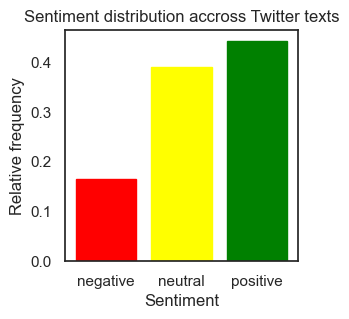

In [42]:
data = df['sentiment']

# Calculate relative frequencies
relative_frequencies = data.value_counts(normalize=True)

# Plotting the histogram
plt.rcParams["figure.figsize"] = [3,3]
bars = plt.bar(relative_frequencies.index, relative_frequencies, width=0.8)

plt.title('Sentiment distribution accross Twitter texts')
plt.xlabel('Sentiment')
plt.ylabel('Relative frequency')
plt.xticks([-1, 0, 1])
plt.xticks((-1, 0, 1), ('negative', 'neutral', 'positive'))
bars[0].set_color('green')
bars[1].set_color('yellow')
bars[2].set_color('red')
plt.show()

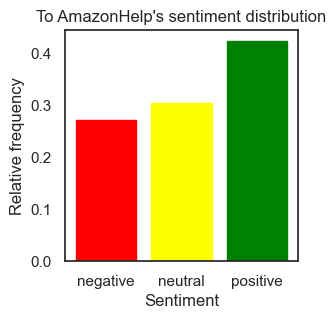

In [43]:
toAmazon = df[df['original_text'].str.contains('Amazon')]
data = toAmazon['sentiment']

# Calculate relative frequencies
relative_frequencies = data.value_counts(normalize=True)

# Plotting the histogram
plt.rcParams["figure.figsize"] = [3,3]
to_amazon_bar = plt.bar(relative_frequencies.index, relative_frequencies, width=0.8)

# clean up the plot, add a title, color the bars, ...
plt.title('To AmazonHelp\'s sentiment distribution')
plt.xlabel('Sentiment')
plt.ylabel('Relative frequency')
plt.xticks([-1, 0, 1])
plt.xticks((-1, 0, 1), ('negative', 'neutral', 'positive'))
to_amazon_bar[0].set_color('green')
to_amazon_bar[1].set_color('yellow')
to_amazon_bar[2].set_color('red')
plt.show()

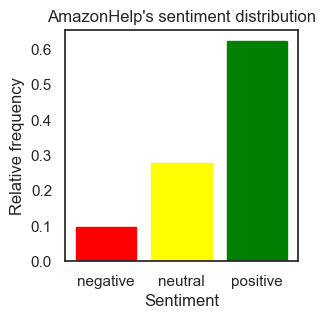

In [44]:
amazonhelp = df[df['author_id'].str.contains('Amazon')]
data = amazonhelp['sentiment']

# Calculate relative frequencies
relative_frequencies = data.value_counts(normalize=True)

# Plotting the histogram
plt.rcParams["figure.figsize"] = [3,3]
amazon_bar = plt.bar(relative_frequencies.index, relative_frequencies, width=0.8)

# clean up the plot, add a title, color the bars, ...
plt.title('AmazonHelp\'s sentiment distribution')
plt.xlabel('Sentiment')
plt.ylabel('Relative frequency')
plt.xticks([-1, 0, 1])
plt.xticks((-1, 0, 1), ('negative', 'neutral', 'positive'))
amazon_bar[0].set_color('green')
amazon_bar[1].set_color('yellow')
amazon_bar[2].set_color('red')
plt.show()

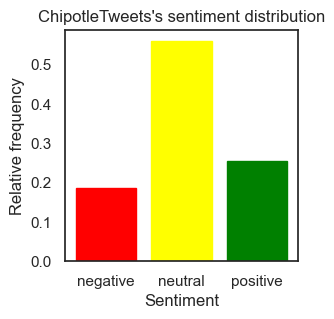

In [45]:
to_chipotletweets = df[df['original_text'].str.contains('Chipotle')]
data = to_chipotletweets['sentiment']

# Calculate relative frequencies
relative_frequencies = data.value_counts(normalize=True)

# Plotting the histogram
plt.rcParams["figure.figsize"] = [3,3]
to_chipotle_bar = plt.bar(relative_frequencies.index, relative_frequencies, width=0.8)

# clean up the plot, add a title, color the bars, ...
plt.title('ChipotleTweets\'s sentiment distribution')
plt.xlabel('Sentiment')
plt.ylabel('Relative frequency')
plt.xticks([-1, 0, 1])
plt.xticks((-1, 0, 1), ('negative', 'neutral', 'positive'))
to_chipotle_bar[0].set_color('yellow')
to_chipotle_bar[1].set_color('green')
to_chipotle_bar[2].set_color('red')
plt.show()

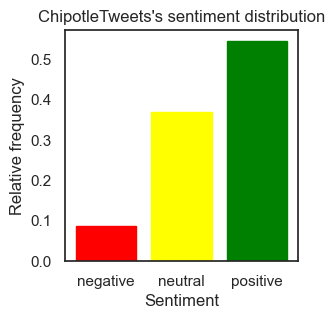

In [46]:
chipotletweets = df[df['author_id'].str.contains('Chipotle')]
data = chipotletweets['sentiment']

# Calculate relative frequencies
relative_frequencies = data.value_counts(normalize=True)

# Plotting the histogram
plt.rcParams["figure.figsize"] = [3,3]
chipotle_bar = plt.bar(relative_frequencies.index, relative_frequencies, width=0.8)

# clean up the plot, add a title, color the bars, ...
plt.title('ChipotleTweets\'s sentiment distribution')
plt.xlabel('Sentiment')
plt.ylabel('Relative frequency')
plt.xticks([-1, 0, 1])
plt.xticks((-1, 0, 1), ('negative', 'neutral', 'positive'))
chipotle_bar[0].set_color('green')
chipotle_bar[1].set_color('yellow')
chipotle_bar[2].set_color('red')
plt.show()

In [47]:
text = " ".join(chat for chat in df.text_nlst)
print ("There are {} words in the combination of all tweets.".format(len(text)))

There are 77937 words in the combination of all tweets.


In [48]:
#create list with all the company names
companies_lst = companies['author_id']
company_lst = sorted(set(companies_lst))

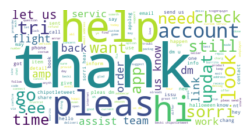

In [49]:
# Create stopword list:
stopwords = set(STOPWORDS)

# create all company names list
stopwords.update(company_lst)
stopwords.update(['https', 'co'])

# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)

# Display the generated image:
# the matplotlib way:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

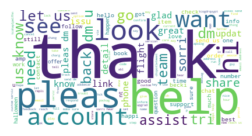

In [50]:
pos_tweets = df[df['sentiment'] == 1]
pos_text = " ".join(chat for chat in pos_tweets.text_nlst)

wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(pos_text)

# Display the generated image:
# the matplotlib way:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

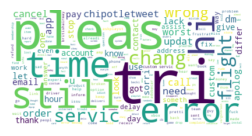

In [51]:
# Next, for negative tweets:
neg_tweets = df[df['sentiment'] == -1]
neg_text = " ".join(chat for chat in neg_tweets.text_nlst)

wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(neg_text)

# Display the generated image:
# the matplotlib way:
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.show()